<a href="https://colab.research.google.com/github/NDani23/CV_notebooks/blob/master/Conv2D_implementation.ipynb" 
target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conv2D implementation (homework)

This notebook was made as a solution for a homework assignment for the "Deep learning in visual informatics" course at BME.

The objective of the notebook is to create a Conv2D implementation and compare it to the PyTorch Conv2D layer. Then use my implementation to learn some pre defined filters (like gauss or sobel filter).

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# Conv layer implementation
class MyConv2D(nn.Module):

  def __init__(self, n, inCH, oCH):
    super().__init__()
    self.n = n
    self.inCH = inCH
    self.oCH = oCH
    self.padding = n // 2

    # Initial random weights
    self.weight = nn.Parameter(torch.randn(oCH, inCH, n, n))

  def forward(self, x):
    # Initialize outputs
    bSize, _ , H, W = x.shape
    output = torch.zeros(bSize, self.oCH, H, W)

    # padding to keep dimensions
    x = F.pad(x, (self.padding, self.padding, self.padding, self.padding), value = 0.)

    # Conv cycle
    for b in range(bSize):
      for oc in range(self.oCH):
        for i in range(H):
          for j in range(W):
            ## Cutting out the conv window
            conv_window = x[b, :, i:i+self.n, j:j+self.n]
            # Convolution
            output[b, oc, i, j] = (conv_window * self.weight[oc]).sum()

    return output

  def __call__(self, x):
    return self.forward(x)


### Comparing solution to PyTorch Conv2D layer

In [3]:
# Function to compare the 2 solution with different batch size, channel size etc...
def conv_compare(bSize, inCH, oCH, n, x, weights):

  #Own conv layer
  my_conv = MyConv2D(n, inCH, oCH)
  my_conv.weight.data = weights

  #PyTorch conv layer
  torch_conv = nn.Conv2d(inCH, oCH, n, padding=n//2, bias = False)
  torch_conv.weight.data = weights

  #Perform convolution
  my_conv_output = my_conv(x)
  torch_conv_output = torch_conv(x)

  #Creating metrics (sum and max of the difference)
  diff = torch.abs(my_conv_output - torch_conv_output)
  abs_diff_sum = diff.sum().item()
  abs_diff_max = diff.max().item()

  return abs_diff_sum, abs_diff_max


In [4]:
# Function to run a test and print the metrics (The OnlyOnes parameter sets whether the initial weights should be random or not)
def run_test(bSize, inCH, oCH, n, H, W, OnlyOnes):
  if OnlyOnes:
    x = torch.ones(bSize, inCH, H, W)
    weights = torch.ones(oCH, inCH, n, n)
  else:
    x = torch.randn(bSize, inCH, H, W)
    weights = torch.randn(oCH, inCH, n, n)


  abs_diff_sum, abs_diff_max = conv_compare(bSize, inCH, oCH, n, x, weights)
  print(f"Configuration: batch_size={bSize}, in_channels={inCH}, out_channels={oCH}, kernel_size={n}, H={H}, W={W}")
  print(f"Sum of absolute differences: {abs_diff_sum}")
  print(f"Max of absolute differences: {abs_diff_max}")


## Run tests

In [5]:
print("\nTest 1: Inputs and weights initialized with only ones")
run_test(bSize=1, inCH=3, oCH=4, n=3, H=32, W=32, OnlyOnes=True)

print("\nTest 2: Inputs and weights initialized with random values")
run_test(bSize=1, inCH=3, oCH=4, n=3, H=32, W=32, OnlyOnes=False)

print("\nTest 3: Bigger batch size")
run_test(bSize=5, inCH=3, oCH=4, n=3, H=32, W=32, OnlyOnes=False)

print("\nTest 4: Fewer output channels")
run_test(bSize=2, inCH=3, oCH=1, n=3, H=32, W=32, OnlyOnes=False)

print("\nTest 5: 1 input, more output channels")
run_test(bSize=2, inCH=1, oCH=16, n=3, H=32, W=32, OnlyOnes=False)

print("\nTest 6: kernel size of 1")
run_test(bSize=2, inCH=3, oCH=4, n=1, H=32, W=32, OnlyOnes=False)

print("\nTest 7: kernel size of 5")
run_test(bSize=2, inCH=3, oCH=4, n=5, H=32, W=32, OnlyOnes=False)

print("\nTest 8: bigger input")
run_test(bSize=2, inCH=3, oCH=4, n=3, H=64, W=64, OnlyOnes=False)


Test 1: Inputs and weights initialized with only ones
Configuration: batch_size=1, in_channels=3, out_channels=4, kernel_size=3, H=32, W=32
Sum of absolute differences: 0.0
Max of absolute differences: 0.0

Test 2: Inputs and weights initialized with random values
Configuration: batch_size=1, in_channels=3, out_channels=4, kernel_size=3, H=32, W=32
Sum of absolute differences: 0.001812154776416719
Max of absolute differences: 4.76837158203125e-06

Test 3: Bigger batch size
Configuration: batch_size=5, in_channels=3, out_channels=4, kernel_size=3, H=32, W=32
Sum of absolute differences: 0.0077798133715987206
Max of absolute differences: 4.291534423828125e-06

Test 4: Fewer output channels
Configuration: batch_size=2, in_channels=3, out_channels=1, kernel_size=3, H=32, W=32
Sum of absolute differences: 0.000990774016827345
Max of absolute differences: 3.814697265625e-06

Test 5: 1 input, more output channels
Configuration: batch_size=2, in_channels=1, out_channels=16, kernel_size=3, H=3

###Training MyConv2D to learn pre-defined filters

#### Download Lena image

In [6]:
!wget https://deeplearning.iit.bme.hu/Public/lena.png --no-check-certificate

--2025-11-08 09:47:51--  https://deeplearning.iit.bme.hu/Public/lena.png
Resolving deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)... 152.66.243.112
Connecting to deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)|152.66.243.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 476211 (465K) [image/png]
Saving to: ‘lena.png’

lena.png            100%[===================>] 465.05K   936KB/s    in 0.5s    

2025-11-08 09:47:55 (936 KB/s) - ‘lena.png’ saved [476211/476211]



### Solution

In [9]:
from PIL import Image
import torchvision.transforms as transforms

def read_image(image_path, size=32):

  # Read and convert image to greyscale
  img = Image.open(image_path).convert('L')

  # Transform to prepare image for convolution
  transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=0.5, std=0.25)
  ])

  # Prepare image (also adding batch dimension)
  img_tensor = transform(img).unsqueeze(0)

  return img_tensor

## Creating filters that I want the model to learn/reproduce

In [8]:
def create_filters():

  #Gauss
  gauss = torch.tensor([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
  ], dtype=torch.float32)

  #Sobel vertical
  sobel_1 = torch.tensor([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
  ], dtype=torch.float32)

  #Sobel horizontal
  sobel_2 = torch.tensor([
        [1,   2,  1],
        [0,   0,  0],
        [-1, -2, -1]
  ], dtype=torch.float32)

  # stacking
  stacked_filters = torch.stack([gauss, sobel_1, sobel_2], dim=0).unsqueeze(1)
  return stacked_filters



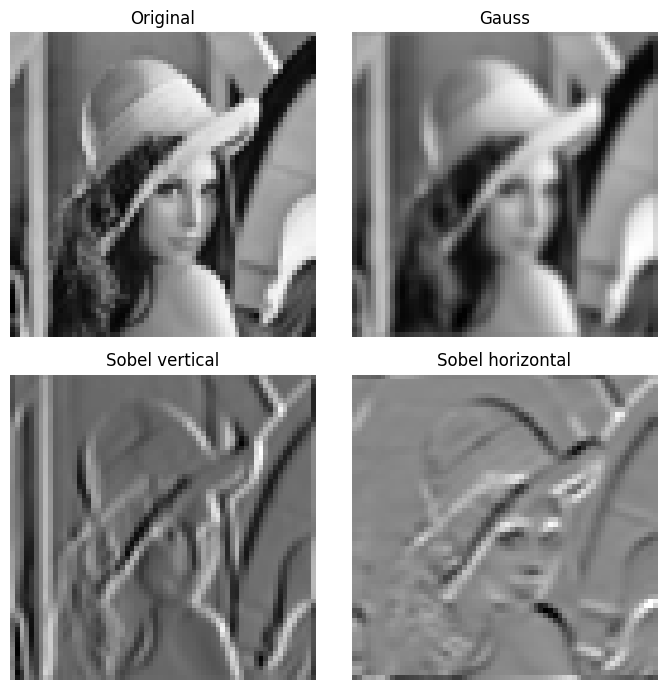

In [14]:
# Creating the training labels using the filters above
import matplotlib.pyplot as plt
from PIL import Image

img = read_image("lena.png", size=64)
filters = create_filters()

#Using PyTorch Conv2D to apply filters
torch_conv = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=3, padding=1, bias = False)
torch_conv.weight.data = filters #Setting the weights to my filters
out=torch_conv(img)
out = out.detach()

plt.figure(figsize=(7,7))

ax1 = plt.subplot(2, 2, 1)
ax1.imshow(img[0, 0].numpy(), cmap='gray')
ax1.set_title('Original')
ax1.axis('off')

ax2 = plt.subplot(2, 2, 2)
ax2.imshow(out[0, 0].numpy(), cmap='gray')
ax2.set_title('Gauss')
ax2.axis('off')

ax3 = plt.subplot(2, 2, 3)
ax3.imshow(out[0, 1].numpy(), cmap='gray')
ax3.set_title('Sobel vertical')
ax3.axis('off')

ax4 = plt.subplot(2, 2, 4)
ax4.imshow(out[0, 2].numpy(), cmap='gray')
ax4.set_title('Sobel horizontal')
ax4.axis('off')

plt.tight_layout()
plt.show()

### Progress bar for training


In [13]:
from IPython.display import HTML, display

def progress(value, max=100):
    return HTML("""
        <progress
            value='{value}'
            max='{max}',
            style='width: 100%'
        >
            {value}
        </progress>
    """.format(value=value, max=max))

### Training MyConv2D

In [15]:
# Train function with hyperparameters for clear testing

import torch.optim as optim
from torch.optim import lr_scheduler

def train_conv(conv_layer, optimizer, numEpoch, scheduler = None):
  criterion = nn.MSELoss()

  trLosses = []
  best_loss = float("inf")
  pred = None

  bar = display(progress(0, numEpoch), display_id=True)

  for epoch in range(numEpoch):
    optimizer.zero_grad()
    new_pred = conv_layer(img)
    loss = criterion(new_pred, out)
    loss.backward()
    optimizer.step()

    trLosses.append(loss.item())

    if scheduler:
      scheduler.step()

    if loss.item() < best_loss:
      best_loss = loss.item()
      pred = new_pred.detach()

    bar.update(progress(epoch + 1, numEpoch))


  return trLosses, best_loss, pred, conv_layer.weight.data

In [16]:
#Training PyTorch conv layer for referencec
conv_layer = nn.Conv2d(1, 3, 3, padding=1, bias = False)
optimizer = optim.SGD(conv_layer.parameters(), lr=0.005, momentum=0.9, nesterov=True, weight_decay=1e-4)
pt_losses, pt_best_loss, pt_pred, pt_weights = train_conv(conv_layer, optimizer, numEpoch=400)

conv_layer = MyConv2D(3, 1, 3)
optimizer = optim.SGD(conv_layer.parameters(), lr=0.005, momentum=0.9, nesterov=True, weight_decay=1e-4)
losses, best_loss, pred, weights = train_conv(conv_layer, optimizer, numEpoch=400)

## Results

Best loss: 0.1462385505437851

Gauss weights:
tensor([[[ 2.2442,  2.6726,  1.8955],
         [-0.7391,  2.4861,  1.0653],
         [ 3.0661,  2.0880,  1.4665]]])

Sobel_1 weights:
tensor([[[ 1.4631,  0.4672, -0.3708],
         [ 1.1077, -1.5018, -1.8851],
         [ 1.7329,  0.5393, -1.4389]]])

Sobel_2 weights:
tensor([[[ 0.6618,  1.9935,  1.5362],
         [ 0.3022, -0.2319, -0.9355],
         [-1.2611, -1.2334, -0.8696]]])


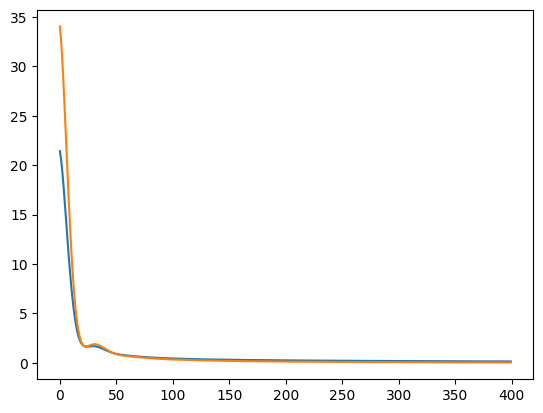

In [17]:
#Learned weights

print(f"Best loss: {best_loss}")
print("\nGauss weights:")
print(weights[0])
print("\nSobel_1 weights:")
print(weights[1])
print("\nSobel_2 weights:")
print(weights[2])

plt.plot(losses)
plt.plot(pt_losses)
plt.show()


### Plotting


 ### Comparing to labels

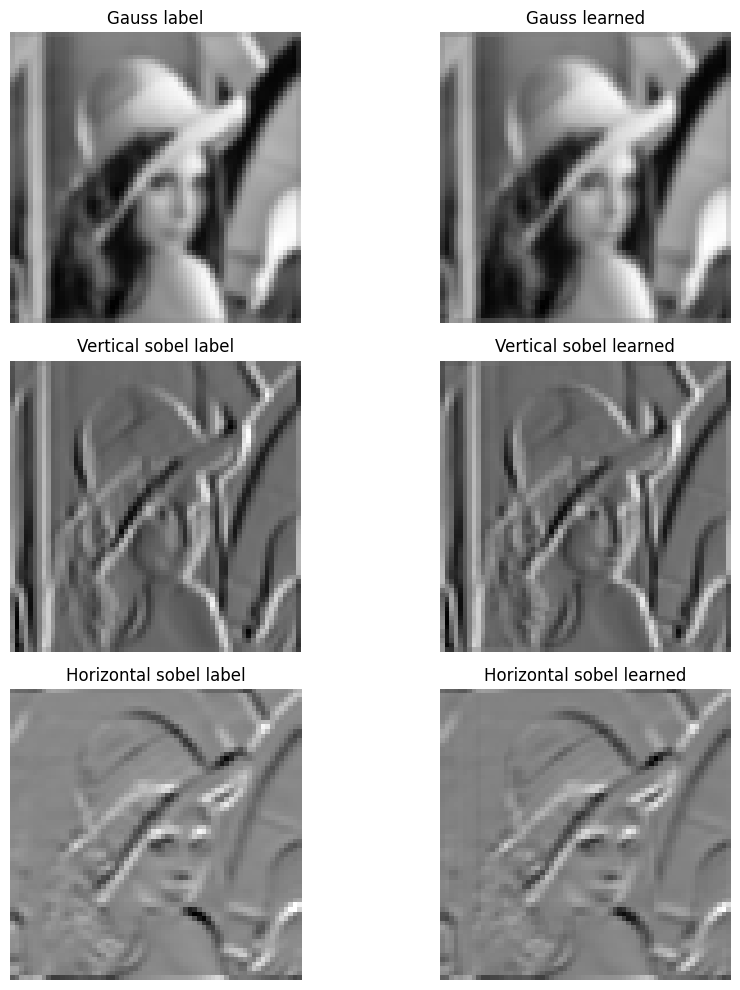

In [22]:
images = pred[0].cpu().numpy()*255.0

plt.figure(figsize=(10,10))

ax1 = plt.subplot(3,2,1)
ax1.imshow(out[0,0].numpy(), cmap='gray')
ax1.set_title('Gauss label')
ax1.axis('off')

ax2 = plt.subplot(3,2,2)
ax2.imshow(images[0], cmap='gray')
ax2.set_title('Gauss learned')
ax2.axis('off')

ax3 = plt.subplot(3,2,3)
ax3.imshow(out[0,1].numpy(), cmap='gray')
ax3.set_title('Vertical sobel label')
ax3.axis('off')

ax4 = plt.subplot(3,2,4)
ax4.imshow(images[1], cmap='gray')
ax4.set_title('Vertical sobel learned')
ax4.axis('off')

ax5 = plt.subplot(3,2,5)
ax5.imshow(out[0,2].numpy(), cmap='gray')
ax5.set_title('Horizontal sobel label')
ax5.axis('off')

ax6 = plt.subplot(3,2,6)
ax6.imshow(images[2], cmap='gray')
ax6.set_title('Horizontal sobel learned')
ax6.axis('off')

plt.tight_layout()
plt.show()